In [3]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("../data/raw/neo.csv")

# Basic inspection
df.head(), df.shape


(        id                 name  est_diameter_min  est_diameter_max  \
 0  2162635  162635 (2000 SS164)          1.198271          2.679415   
 1  2277475    277475 (2005 WK4)          0.265800          0.594347   
 2  2512244   512244 (2015 YE18)          0.722030          1.614507   
 3  3596030          (2012 BV13)          0.096506          0.215794   
 4  3667127          (2014 GE35)          0.255009          0.570217   
 
    relative_velocity  miss_distance orbiting_body  sentry_object  \
 0       13569.249224   5.483974e+07         Earth          False   
 1       73588.726663   6.143813e+07         Earth          False   
 2      114258.692129   4.979872e+07         Earth          False   
 3       24764.303138   2.543497e+07         Earth          False   
 4       42737.733765   4.627557e+07         Earth          False   
 
    absolute_magnitude  hazardous  
 0               16.73      False  
 1               20.00       True  
 2               17.83      False  
 3    

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [5]:
# check for nulls
df.isna().sum().sort_values(ascending=False)

id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

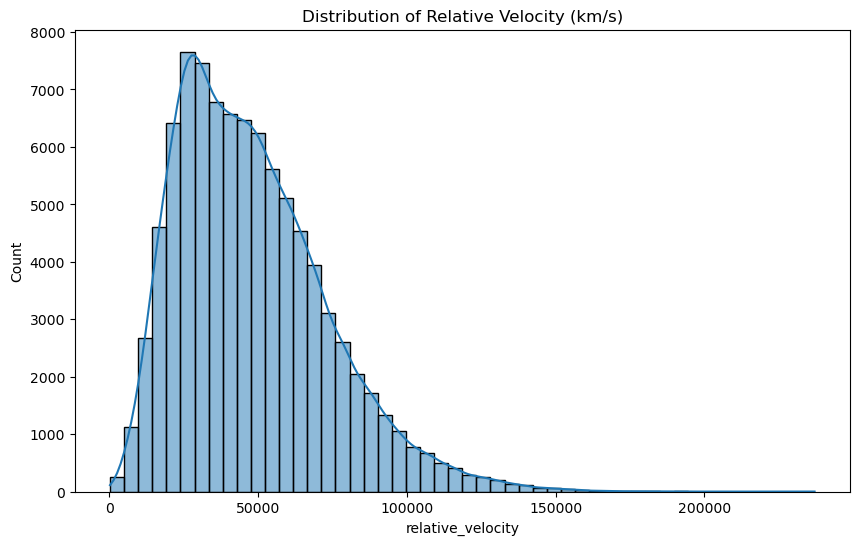

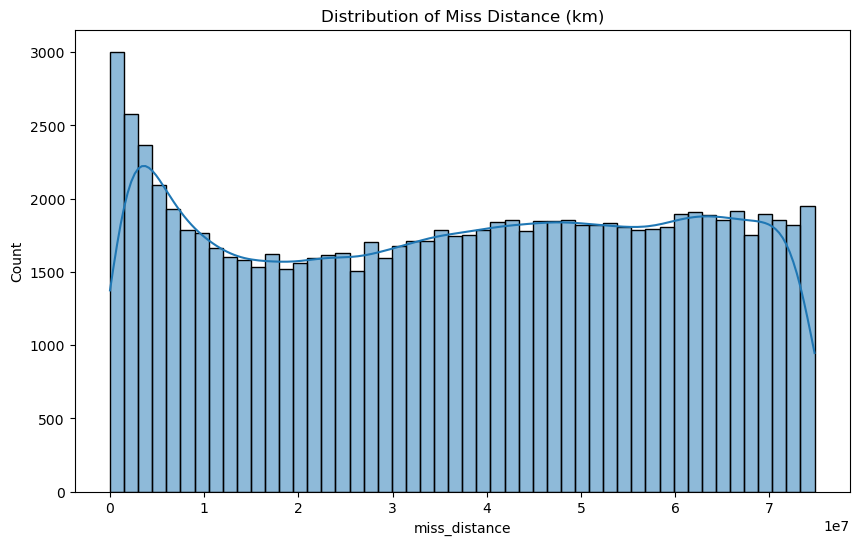

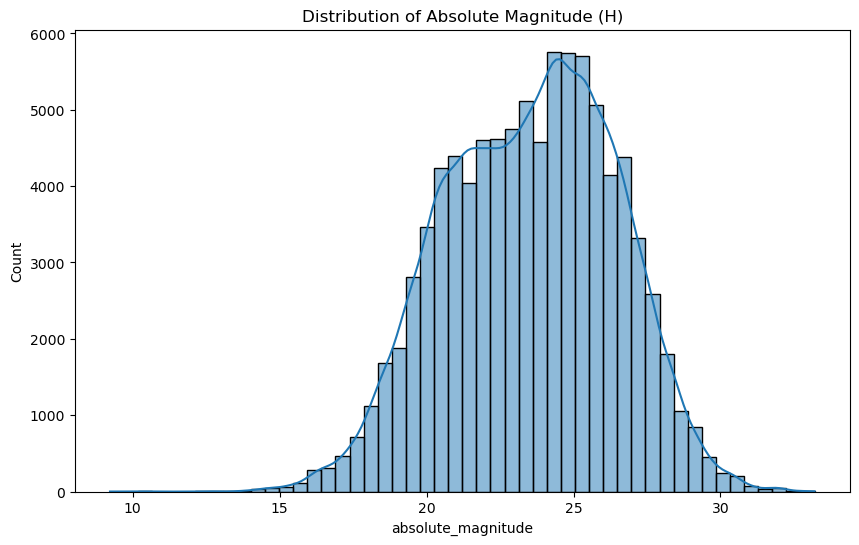

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['relative_velocity'], bins=50, kde=True)
plt.title("Distribution of Relative Velocity (km/s)")
plt.show()


plt.figure(figsize=(10,6))
sns.histplot(df['miss_distance'], bins=50, kde=True)
plt.title("Distribution of Miss Distance (km)")
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df['absolute_magnitude'], bins=50, kde=True)
plt.title("Distribution of Absolute Magnitude (H)")
plt.show()


In [ ]:
# Relative velocity distribution:
    # - most objects move at "normal" speeds
    # - a few are extremely fast
    # - velocity is a strong risk signal when combined with distance
df['velocity_z'] = (df['relative_velocity'] - df['relative_velocity'].mean()) / df['relative_velocity'].std()

# Distribution of miss distance
    # - a huge spike at small distances and a long stetched tail
    # - we need to log transform miss distance
    # - raw values will distort models


# Absolute magnitude distribution
    # - most neos are small and faint, a few are large and bright
    # - a good proxy for size (lower h = bigger object

In [9]:
# Feature engineering
## 1. log transforms
df['log_miss_distance'] = np.log1p(df['miss_distance'])
df['log_velocity'] = np.log1p(df['relative_velocity'])

## 2. diameter midpoint (MUST come before kinetic_proxy)
df['diameter_mid'] = (df['est_diameter_min'] + df['est_diameter_max']) / 2

## 3. size × velocity composite
df['kinetic_proxy'] = df['diameter_mid'] * df['relative_velocity']

## 4. z-scores
df['velocity_z'] = (df['relative_velocity'] - df['relative_velocity'].mean()) / df['relative_velocity'].std()
df['distance_z'] = (df['miss_distance'] - df['miss_distance'].mean()) / df['miss_distance'].std()

## 5. preliminary risk score
df['risk_score'] = (
    df['velocity_z'] * 0.4 +
    df['log_miss_distance'] * -0.5 +
    df['diameter_mid'] * 0.1
)


In [10]:
df[['diameter_mid', 'kinetic_proxy', 'risk_score']].head()
 

,diameter_mid,kinetic_proxy,risk_score
0,1.938843,26308.642289,-9.261641
1,0.430073,31648.556395,-8.520149
2,1.168268,133484.815463,-7.698136
3,0.156150,3866.951529,-8.878721
4,0.412613,17634.132763,-8.868079


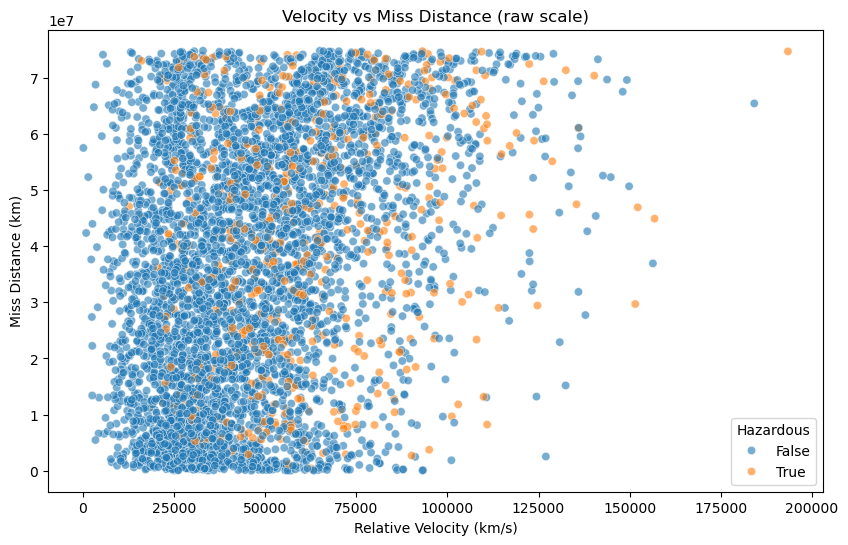

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),  # sample for speed
    x='relative_velocity',
    y='miss_distance',
    hue='hazardous',
    alpha=0.6
)
plt.title("Velocity vs Miss Distance (raw scale)")
plt.xlabel("Relative Velocity (km/s)")
plt.ylabel("Miss Distance (km)")
plt.legend(title="Hazardous")
plt.show()

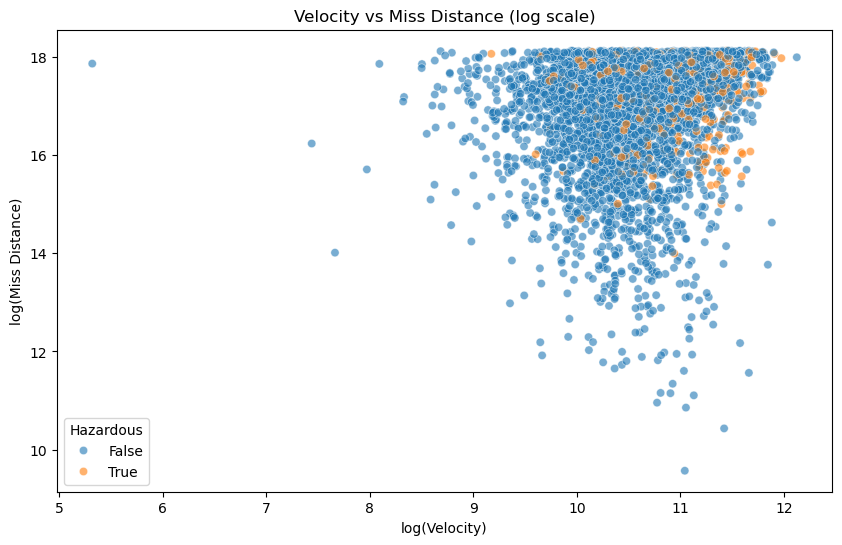

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='log_velocity',
    y='log_miss_distance',
    hue='hazardous',
    alpha=0.6
)
plt.title("Velocity vs Miss Distance (log scale)")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")
plt.legend(title="Hazardous")
plt.show()

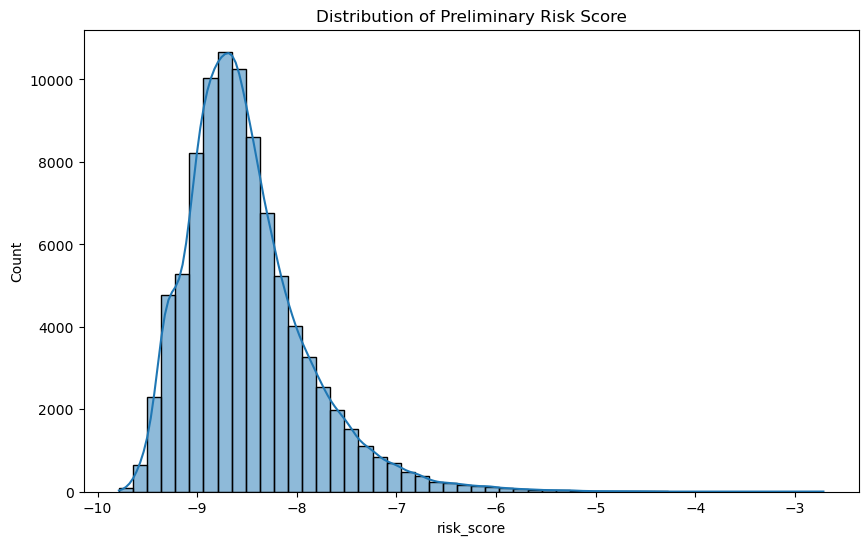

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['risk_score'], bins=50, kde=True)
plt.title("Distribution of Preliminary Risk Score")
plt.show()


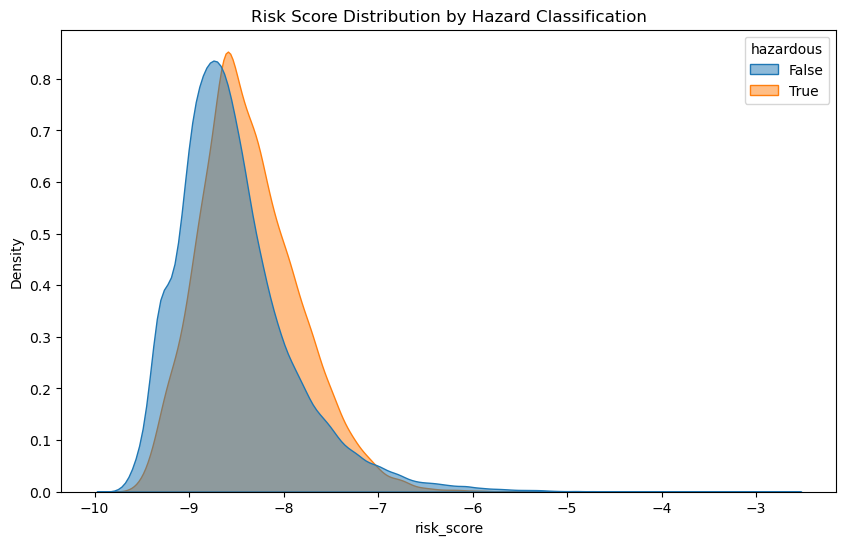

In [14]:
# compare hazardous vs non-hazardous
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x='risk_score',
    hue='hazardous',
    fill=True,
    common_norm=False,
    alpha=0.5
)
plt.title("Risk Score Distribution by Hazard Classification")
plt.show()


In [ ]:
# There are non‑hazardous objects that look risky and hazardous objects that look normal

In [15]:
from sklearn.ensemble import IsolationForest

# Features for anomaly detection
features = [
    'log_velocity',
    'log_miss_distance',
    'diameter_mid',
    'kinetic_proxy',
    'absolute_magnitude',
    'risk_score'
]

X = df[features]

# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=300,
    contamination=0.01,   # top 1% most anomalous
    random_state=42
)

df['anomaly_score'] = iso.fit_predict(X)
df['anomaly_value'] = iso.decision_function(X)


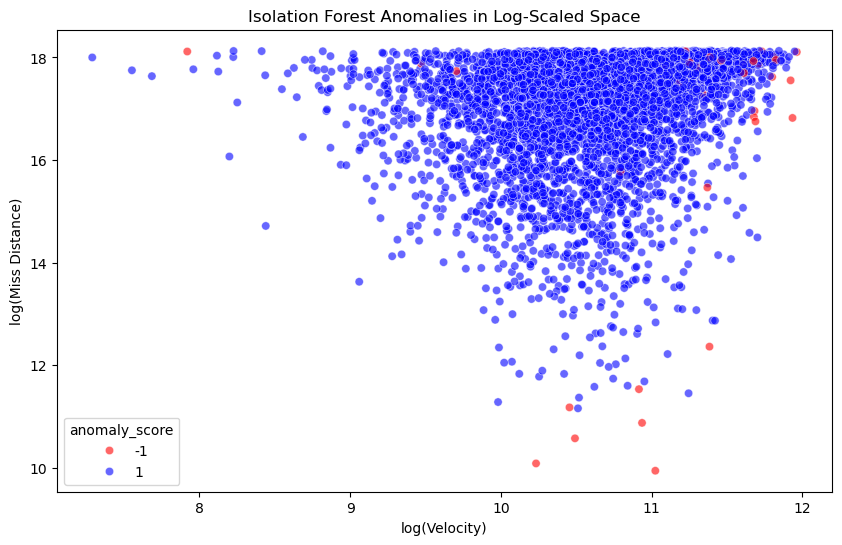

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='log_velocity',
    y='log_miss_distance',
    hue='anomaly_score',
    palette={1: 'blue', -1: 'red'},
    alpha=0.6
)
plt.title("Isolation Forest Anomalies in Log-Scaled Space")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")
plt.show()


In [17]:
# rank the anomalies
# Sort by anomaly_value (lower = more anomalous)
top_anomalies = df.sort_values('anomaly_value').head(20)

top_anomalies[['id', 'name', 'relative_velocity', 'miss_distance', 
               'diameter_mid', 'absolute_magnitude', 
               'risk_score', 'anomaly_value']]


,id,name,relative_velocity,miss_distance,diameter_mid,absolute_magnitude,risk_score,anomaly_value
12709,2000433,433 Eros (A898 PA),15884.252623,5.468808e+07,37.285727,10.31,-5.688957,-0.132463
36418,2001036,1036 Ganymed (A924 UB),51496.923293,5.372124e+07,61.311595,9.23,-2.714256,-0.131729
37651,2000433,433 Eros (A898 PA),21402.705247,2.672952e+07,37.285727,10.31,-5.243747,-0.129998
56533,2000433,433 Eros (A898 PA),21761.703426,3.120592e+07,37.285727,10.31,-5.315489,-0.128009
22026,2003200,3200 Phaethon (1983 TB),134806.935530,1.808573e+07,5.669472,14.40,-6.416623,-0.122365
60218,2002212,2212 Hephaistos (1978 SB),135956.251475,4.478821e+07,8.463356,13.53,-6.572469,-0.120187
50832,2003200,3200 Phaethon (1983 TB),114797.864507,1.031203e+07,5.669472,14.40,-6.452150,-0.118406
4445,2016960,16960 (1998 QS52),149936.050762,5.424840e+07,5.565993,14.44,-6.736937,-0.116522
16895,2001866,1866 Sisyphus (1972 XA),96530.774890,7.402691e+07,13.981141,12.44,-6.895425,-0.115895
87849,2005143,5143 Heracles (1991 VL),122333.637277,4.581021e+07,6.420112,14.13,-7.003509,-0.111809


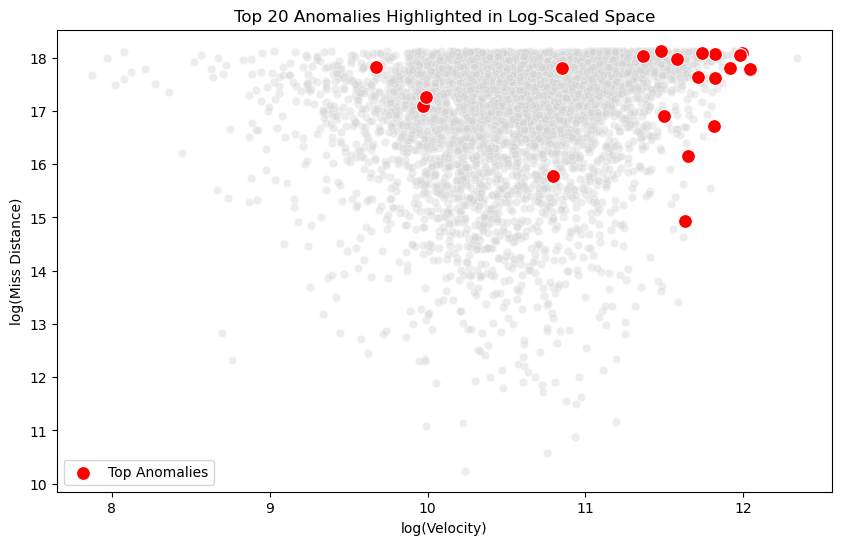

In [18]:
# visualize top anomalies
subset = top_anomalies

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='log_velocity',
    y='log_miss_distance',
    color='lightgray',
    alpha=0.4
)

sns.scatterplot(
    data=subset,
    x='log_velocity',
    y='log_miss_distance',
    color='red',
    s=100,
    label='Top Anomalies'
)

plt.title("Top 20 Anomalies Highlighted in Log-Scaled Space")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")
plt.legend()
plt.show()


In [19]:
top_anomalies[['id', 'name', 
               'relative_velocity', 
               'miss_distance', 
               'diameter_mid', 
               'absolute_magnitude', 
               'risk_score', 
               'anomaly_value',
               'hazardous']]

,id,name,relative_velocity,miss_distance,diameter_mid,absolute_magnitude,risk_score,anomaly_value,hazardous
12709,2000433,433 Eros (A898 PA),15884.252623,5.468808e+07,37.285727,10.31,-5.688957,-0.132463,False
36418,2001036,1036 Ganymed (A924 UB),51496.923293,5.372124e+07,61.311595,9.23,-2.714256,-0.131729,False
37651,2000433,433 Eros (A898 PA),21402.705247,2.672952e+07,37.285727,10.31,-5.243747,-0.129998,False
56533,2000433,433 Eros (A898 PA),21761.703426,3.120592e+07,37.285727,10.31,-5.315489,-0.128009,False
22026,2003200,3200 Phaethon (1983 TB),134806.935530,1.808573e+07,5.669472,14.40,-6.416623,-0.122365,True
60218,2002212,2212 Hephaistos (1978 SB),135956.251475,4.478821e+07,8.463356,13.53,-6.572469,-0.120187,False
50832,2003200,3200 Phaethon (1983 TB),114797.864507,1.031203e+07,5.669472,14.40,-6.452150,-0.118406,True
4445,2016960,16960 (1998 QS52),149936.050762,5.424840e+07,5.565993,14.44,-6.736937,-0.116522,True
16895,2001866,1866 Sisyphus (1972 XA),96530.774890,7.402691e+07,13.981141,12.44,-6.895425,-0.115895,False
87849,2005143,5143 Heracles (1991 VL),122333.637277,4.581021e+07,6.420112,14.13,-7.003509,-0.111809,False


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Features for the interpretable model
features = [
    'log_velocity',
    'log_miss_distance',
    'diameter_mid',
    'absolute_magnitude',
    'kinetic_proxy'
]

X = df[features]
y = df['hazardous'].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic regression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.91      0.99      0.95     16400
           1       0.65      0.10      0.17      1768

    accuracy                           0.91     18168
   macro avg       0.78      0.55      0.56     18168
weighted avg       0.89      0.91      0.87     18168

ROC AUC: 0.8850232107383291


In [21]:
import numpy as np
coef_table = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
})
coef_table.sort_values('odds_ratio', ascending=False)


,feature,coefficient,odds_ratio
0,log_velocity,0.603564,1.828624
4,kinetic_proxy,-0.000005,0.999995
1,log_miss_distance,-0.612081,0.542221
3,absolute_magnitude,-1.194151,0.302961
2,diameter_mid,-3.085066,0.045727


In [22]:
df['hazard_probability'] = model.predict_proba(df[features])[:, 1]


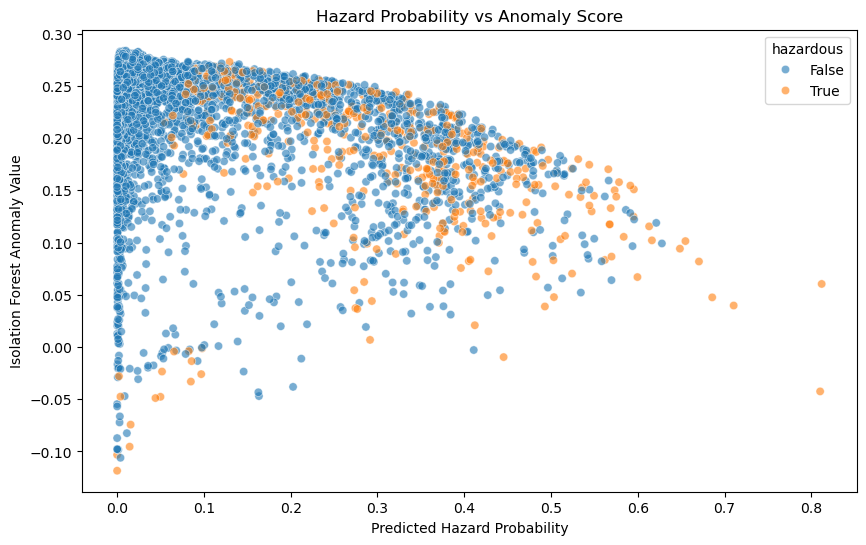

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(5000),
    x='hazard_probability',
    y='anomaly_value',
    hue='hazardous',
    alpha=0.6
)
plt.title("Hazard Probability vs Anomaly Score")
plt.xlabel("Predicted Hazard Probability")
plt.ylabel("Isolation Forest Anomaly Value")
plt.show()


In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['norm_hazard_prob'] = scaler.fit_transform(df[['hazard_probability']])
df['norm_anomaly'] = scaler.fit_transform(df[['anomaly_value']])
df['norm_risk_score'] = scaler.fit_transform(df[['risk_score']])


In [25]:
df['final_risk_index'] = (
    0.5 * df['norm_hazard_prob'] +     # supervised
    0.3 * (1 - df['norm_anomaly']) +   # unsupervised (invert: lower anomaly_value = riskier)
    0.2 * df['norm_risk_score']        # engineered
)

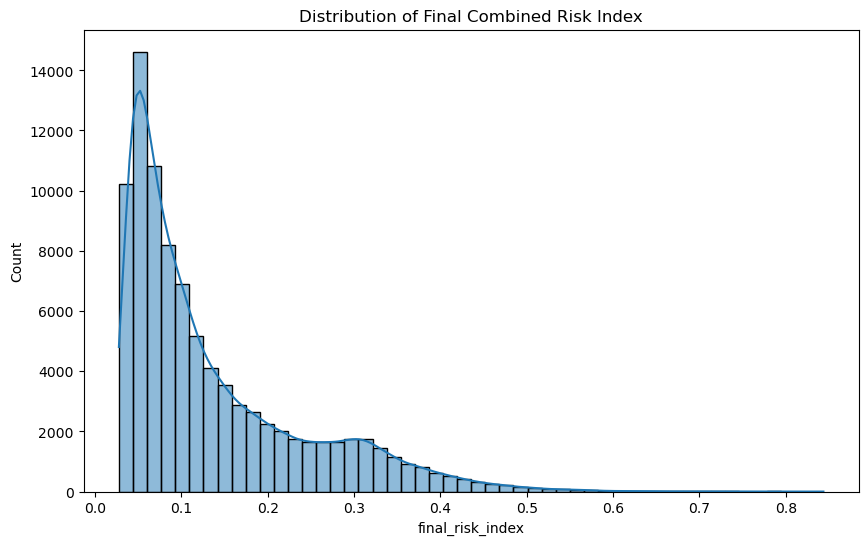

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(df['final_risk_index'], bins=50, kde=True)
plt.title("Distribution of Final Combined Risk Index")
plt.show()

In [27]:
df.sort_values('final_risk_index', ascending=False).head(20)[[
    'id', 'name', 'relative_velocity', 'miss_distance',
    'diameter_mid', 'absolute_magnitude',
    'hazard_probability', 'anomaly_value',
    'final_risk_index', 'hazardous'
]]


,id,name,relative_velocity,miss_distance,diameter_mid,absolute_magnitude,hazard_probability,anomaly_value,final_risk_index,hazardous
69807,3729835,(2015 TB145),125807.719190,4.868071e+05,0.422224,20.04,0.913719,-0.020813,0.843622,True
4802,3131063,(2002 NY40),75226.687788,5.269744e+05,0.681620,19.00,0.920658,-0.002282,0.811077,True
17142,3263453,(2004 XP14),62664.322585,4.324384e+05,0.566947,19.40,0.917746,0.007651,0.799217,True
2472,3789399,(2017 VW13),40792.770407,1.432727e+05,0.311561,20.70,0.897687,0.016398,0.787159,True
17150,2612901,612901 (2004 XP14),62664.322601,4.324384e+05,0.471566,19.80,0.905233,0.017352,0.785187,True
47388,3670721,(2014 JO25),120810.256121,1.758044e+06,1.184521,17.80,0.810027,-0.042477,0.784626,True
83570,2231937,231937 (2001 FO32),123887.394193,2.016392e+06,1.310819,17.58,0.762049,-0.048903,0.762978,True
465,3070541,(2001 EC),80976.423144,1.471204e+06,0.800834,18.65,0.864574,0.010624,0.759744,True
2988,3102719,(2001 YB5),110118.237589,8.321449e+05,0.284147,20.90,0.810437,0.008639,0.751396,True
61926,2388188,388188 (2006 DP14),97683.599040,2.398364e+06,0.672268,19.03,0.832980,0.021470,0.734997,True


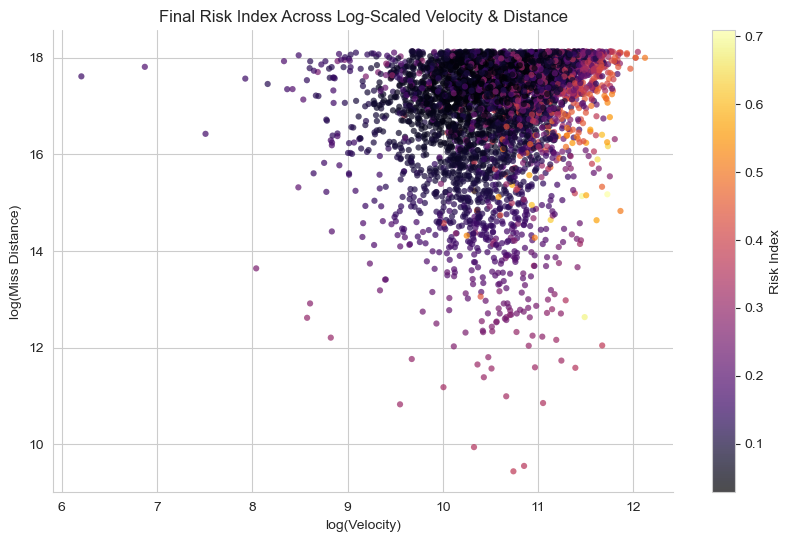

In [37]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Sample once so all arrays match
sample = df.sample(5000)

# Create the scatter with matplotlib (for colorbar)
points = plt.scatter(
    sample['log_velocity'],
    sample['log_miss_distance'],
    c=sample['final_risk_index'],
    cmap='inferno',
    alpha=0.7,
    s=20,
    linewidths=0,
)

# Overlay seaborn styling (optional but makes it pretty)
sns.despine()

plt.title("Final Risk Index Across Log-Scaled Velocity & Distance")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")

# Add colorbar
cbar = plt.colorbar(points)
cbar.set_label("Risk Index")

plt.show()


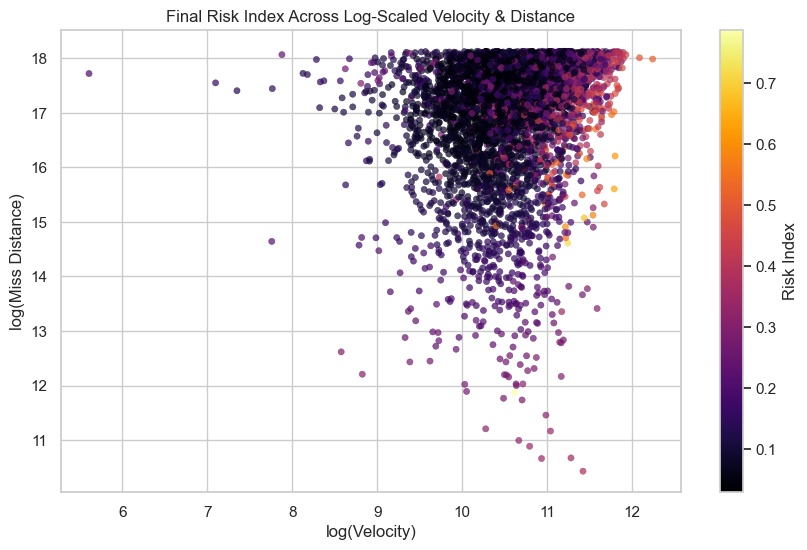

In [40]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

# Sample once so everything aligns
sample = df.sample(5000)

# 1. Create seaborn scatterplot (beautiful)
ax = sns.scatterplot(
    data=sample,
    x='log_velocity',
    y='log_miss_distance',
    hue='final_risk_index',
    palette='inferno',
    alpha=0.7,
    s=20,
    edgecolor=None,
    legend=False
)

# 2. Build a proper mappable for the colorbar
norm = plt.Normalize(sample['final_risk_index'].min(), sample['final_risk_index'].max())
sm = plt.cm.ScalarMappable(cmap='inferno', norm=norm)
sm.set_array([])

# 3. Attach colorbar to the SAME axes seaborn used
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Risk Index")

plt.title("Final Risk Index Across Log-Scaled Velocity & Distance")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")

plt.show()


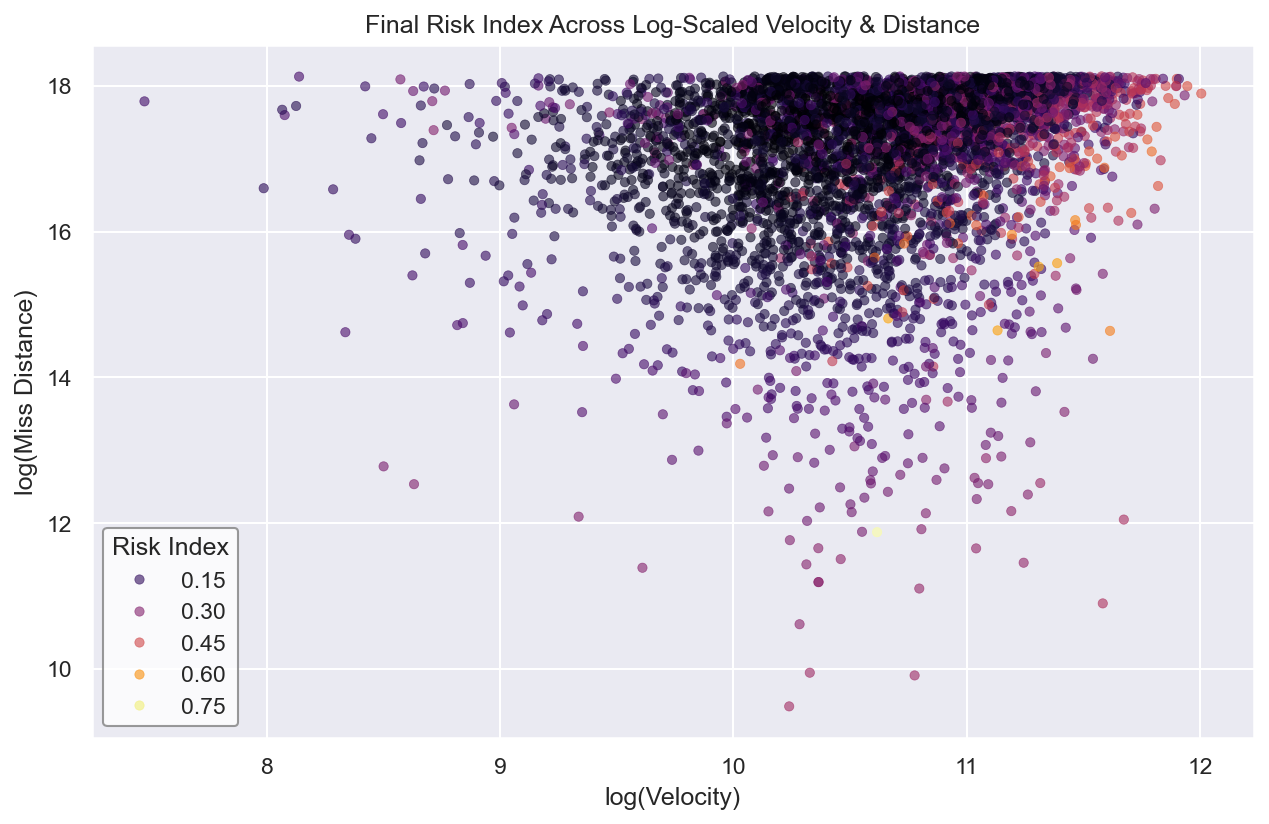

In [46]:
plt.figure(figsize=(10,6))
sns.set_theme(style="darkgrid", rc={"figure.dpi": 150})

sns.scatterplot(
    data=df.sample(5000),
    x='log_velocity',
    y='log_miss_distance',
    hue='final_risk_index',
    palette='inferno',
    alpha=0.6,
    s=20,
    edgecolor=None
)

plt.title("Final Risk Index Across Log-Scaled Velocity & Distance")
plt.xlabel("log(Velocity)")
plt.ylabel("log(Miss Distance)")
plt.legend(title="Risk Index", frameon=True, facecolor="white", edgecolor="gray")
plt.savefig("final_risk_index_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [45]:
plt.savefig("final_risk_index_plot.png", dpi=300, bbox_inches="tight")


<Figure size 960x720 with 0 Axes>